# 03 — Grad-CAM Analysis

Visualises **what each of the 5 models attends to** on the same CXR, per pathology label.

**Workflow**
1. Edit the **CONFIG** cell — set paths to your 5 checkpoints.
2. Run all cells (Kernel → Restart & Run All).
3. For each label a figure is produced: rows = top-N highest-confidence true-positive images, columns = original X-ray + Grad-CAM overlay for each model.

| Model | Trained on | Bias |
|-------|------------|------|
| `original` | clean CXRs | none |
| `gb` | Gaussian-blurred | texture |
| `ps` | patch-shuffled | texture |
| `ce` | Canny edges | shape |
| `pr` | patch-rotated | shape |

In [1]:
# ── Must be set before numpy / torch are imported anywhere ────────────────────
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['OMP_NUM_THREADS']       = '1'

# ============================================================
#  USER CONFIG — only this cell needs editing
# ============================================================
from pathlib import Path

# Paths to each model checkpoint (relative to repo root, or absolute)
CHECKPOINTS = {
    'original': 'results/ARCHIVE_NICK/3/original/best_model.pth',
    'gb':       'results/ARCHIVE_NICK/3/gb/best_model.pth',
    'ps':       'results/ARCHIVE_NICK/3/ps/best_model.pth',
    'ce':       'results/ARCHIVE_NICK/3/ce/best_model.pth',
    'pr':       'results/ARCHIVE_NICK/3/pr/best_model.pth',
}

# Test manifest parquet and image root (relative to repo root)
TEST_MANIFEST = 'src/data/test_manifest.parquet'
IMAGE_ROOT    = 'src/data/1'

# How many top true-positive images to visualise per label
TOP_N = 3

# Labels to visualise — set to None to use all labels found in the checkpoint
# Start with just Edema to verify GradCAM is working before running all labels
LABELS_TO_VIZ = ['Edema']

# Which model's scores rank/select the top images (all 5 still appear in the panel)
SCORING_MODEL = 'original'

# Where to save output figures (relative to repo root)
OUTPUT_DIR = 'results/grad_cam'

# Batch size for the scoring pass — lower if GPU memory is tight
SCORE_BATCH_SIZE = 32
# ============================================================

In [2]:
import sys
import types
import warnings
import numpy as np
import polars as pl
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.cm as mpl_cm
from PIL import Image
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

# ── Resolve repo root ─────────────────────────────────────────────────────────
_cwd = Path().resolve()
REPO_ROOT = next(
    (p for p in [_cwd, *_cwd.parents]
     if (p / 'pyproject.toml').exists() or (p / 'src').is_dir()),
    _cwd,
)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.models.densenet import DenseNetClassifier

DEVICE    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_IMG_ROOT = REPO_ROOT / IMAGE_ROOT
_OUT_DIR  = REPO_ROOT / OUTPUT_DIR
_OUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINTS = {k: REPO_ROOT / v for k, v in CHECKPOINTS.items()}

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
_preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print(f'Device    : {DEVICE}')
print(f'Repo root : {REPO_ROOT}')
print(f'Image root: {_IMG_ROOT}')
print(f'Output dir: {_OUT_DIR}')

Device    : cuda
Repo root : C:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis
Image root: C:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\src\data\1
Output dir: C:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\results\grad_cam


c:\Users\nolot\anaconda3\envs\DL_PROJECT\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ── Grad-CAM ──────────────────────────────────────────────────────────────────

def _patch_densenet_relu(model):
    """
    Fix torchvision DenseNet's inplace ReLU that corrupts GradCAM activations.

    torchvision DenseNet uses F.relu(features, inplace=True) in its forward()
    method. This modifies the activation tensor in-place AFTER the forward hook
    has saved a reference to it, corrupting the saved activations and producing
    all-zero (blank) heatmaps. Replacing with inplace=False fixes this.
    """
    def _forward(inner_self, x):
        features = inner_self.features(x)
        out = F.relu(features, inplace=False)  # inplace=True corrupts GradCAM hooks
        out = F.adaptive_avg_pool2d(out, (1, 1))
        out = torch.flatten(out, 1)
        out = inner_self.classifier(out)
        return out
    model.backbone.forward = types.MethodType(_forward, model.backbone)


class GradCAM:
    """Grad-CAM for DenseNetClassifier. Hooks backbone.features (last feature map)."""

    def __init__(self, model):
        self.model  = model
        self._acts  = None
        self._grads = None
        model.backbone.features.register_forward_hook(self._fwd_hook)
        model.backbone.features.register_full_backward_hook(self._bwd_hook)

    def _fwd_hook(self, module, inp, out):
        self._acts = out.detach().clone()

    def _bwd_hook(self, module, grad_in, grad_out):
        self._grads = grad_out[0].detach().clone()

    def generate(self, tensor, class_idx):
        """Return a (224, 224) float32 heatmap normalised to [0, 1]."""
        self.model.zero_grad()
        output = self.model(tensor.to(DEVICE))
        output[0, class_idx].backward()

        weights = self._grads.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self._acts).sum(dim=1)).squeeze(0)
        cam     = F.interpolate(
            cam.unsqueeze(0).unsqueeze(0),
            size=(224, 224), mode='bilinear', align_corners=False
        ).squeeze().cpu().numpy()
        lo, hi = cam.min(), cam.max()
        if hi - lo < 1e-6:
            print(f'  WARNING: flat CAM for class {class_idx} — heatmap will appear blank'
                  ' (check _patch_densenet_relu was applied)')
        return ((cam - lo) / (hi - lo + 1e-8)).astype(np.float32)


def overlay(pil_img, cam, alpha=0.50):
    heatmap = mpl_cm.inferno(cam)[:, :, :3]
    img_arr = np.array(pil_img.convert('RGB').resize((224, 224))) / 255.0
    return np.clip((1 - alpha) * img_arr + alpha * heatmap, 0, 1)


def load_pil(rel_path):
    return Image.open(_IMG_ROOT / rel_path).convert('RGB').resize((224, 224))


def load_tensor(rel_path):
    return _preprocess(Image.open(_IMG_ROOT / rel_path).convert('RGB')).unsqueeze(0)


print('GradCAM ready.')

GradCAM ready.


In [5]:
# ── Load all 5 models ─────────────────────────────────────────────────────────

def _load_model(ckpt_path):
    ckpt    = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    cfg     = ckpt.get('config', {})
    labels  = cfg.get('labels') or []
    variant = cfg.get('model', {}).get('name', 'densenet121')
    if not labels:
        from src.data.chexpert_dataset import CheXpertDataset
        labels = CheXpertDataset.DEFAULT_LABELS
    model = DenseNetClassifier(
        num_classes=len(labels), pretrained=False, variant=variant
    ).to(DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    # Patch inplace ReLU BEFORE registering GradCAM hooks — torchvision DenseNet
    # uses F.relu(..., inplace=True) which corrupts saved activations post-forward
    _patch_densenet_relu(model)
    return model, list(labels)


models       = {}
model_labels = {}
grad_cams    = {}

for name, ckpt_path in CHECKPOINTS.items():
    if not Path(ckpt_path).exists():
        print(f'  SKIP {name}: {ckpt_path} not found')
        continue
    m, lbls            = _load_model(ckpt_path)
    models[name]       = m
    model_labels[name] = lbls
    grad_cams[name]    = GradCAM(m)
    epoch = torch.load(ckpt_path, map_location='cpu', weights_only=False).get('epoch', '?')
    print(f'  {name:10s}  labels={len(lbls):2d}  epoch={epoch}')

# Labels common to all loaded models, preserving original order
label_sets    = [set(v) for v in model_labels.values()]
common_labels = [l for l in model_labels[list(models.keys())[0]]
                 if all(l in s for s in label_sets)]

if LABELS_TO_VIZ:
    common_labels = [l for l in LABELS_TO_VIZ if l in common_labels]

print(f'\nModels loaded  : {list(models.keys())}')
print(f'Labels to viz  : {common_labels}')

  original    labels=14  epoch=5
  gb          labels=14  epoch=4
  ps          labels=14  epoch=5
  ce          labels=14  epoch=6
  pr          labels=14  epoch=5

Models loaded  : ['original', 'gb', 'ps', 'ce', 'pr']
Labels to viz  : ['Edema']


In [6]:
# ── Score full test set → find top-N true positives per label ─────────────────

class _ManifestDataset(Dataset):
    def __init__(self, parquet_path, image_root, label_names, transform):
        df = pl.read_parquet(parquet_path)
        available = [l for l in label_names if l in df.columns]
        self.paths       = df['Path'].to_list()
        self.labels      = df.select(available).to_numpy().astype(np.float32)
        self.label_names = available
        self.root        = Path(image_root)
        self.tfm         = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        try:
            tensor = self.tfm(Image.open(self.root / self.paths[idx]).convert('RGB'))
        except Exception:
            tensor = torch.zeros(3, 224, 224)
        return tensor, self.labels[idx], self.paths[idx]


assert SCORING_MODEL in models, f"SCORING_MODEL='{SCORING_MODEL}' not found in loaded models"

test_ds = _ManifestDataset(
    parquet_path = REPO_ROOT / TEST_MANIFEST,
    image_root   = _IMG_ROOT,
    label_names  = model_labels[SCORING_MODEL],
    transform    = _preprocess,
)
test_loader = DataLoader(
    test_ds, batch_size=SCORE_BATCH_SIZE,
    shuffle=False, num_workers=0,
)

print(f'Scoring {len(test_ds)} images with "{SCORING_MODEL}" model...')

all_probs, all_gt, all_paths = [], [], []

models[SCORING_MODEL].eval()
with torch.no_grad():
    for imgs, gt, paths in tqdm(test_loader, desc='Scoring'):
        probs = torch.sigmoid(models[SCORING_MODEL](imgs.to(DEVICE))).cpu().numpy()
        all_probs.append(probs)
        all_gt.append(gt.numpy())
        all_paths.extend(paths)

all_probs = np.vstack(all_probs)
all_gt    = np.vstack(all_gt)
scoring_labels = test_ds.label_names

# Build top-N per label
top_images = {}
for label in common_labels:
    if label not in scoring_labels:
        print(f'  {label}: not in test manifest, skipping')
        continue
    li    = scoring_labels.index(label)
    probs = all_probs[:, li]
    gt    = all_gt[:, li]

    tp_mask = (gt == 1)
    if tp_mask.sum() == 0:
        print(f'  {label}: no ground-truth positives — using top predicted scores instead')
        tp_mask = np.ones(len(probs), dtype=bool)

    tp_idx  = np.where(tp_mask)[0]
    top_k   = tp_idx[np.argsort(probs[tp_mask])[::-1][:TOP_N]]
    top_images[label] = [(all_paths[i], float(gt[i]), float(probs[i])) for i in top_k]

print(f'\nTop-{TOP_N} images per label:')
for label, samples in top_images.items():
    scores = ', '.join(f'{p:.3f}' for _, _, p in samples)
    print(f'  {label:<35} [{scores}]')

Scoring 202 images with "original" model...


Scoring: 100%|██████████| 7/7 [00:00<00:00,  8.80it/s]


Top-3 images per label:
  Edema                               [0.348, 0.348, 0.348]


Saved: C:\Users\nolot\Desktop\Deep Learning\PROJECT\chest-radiology-deep-learning-bias-analysis\results\grad_cam\gradcam_edema.png


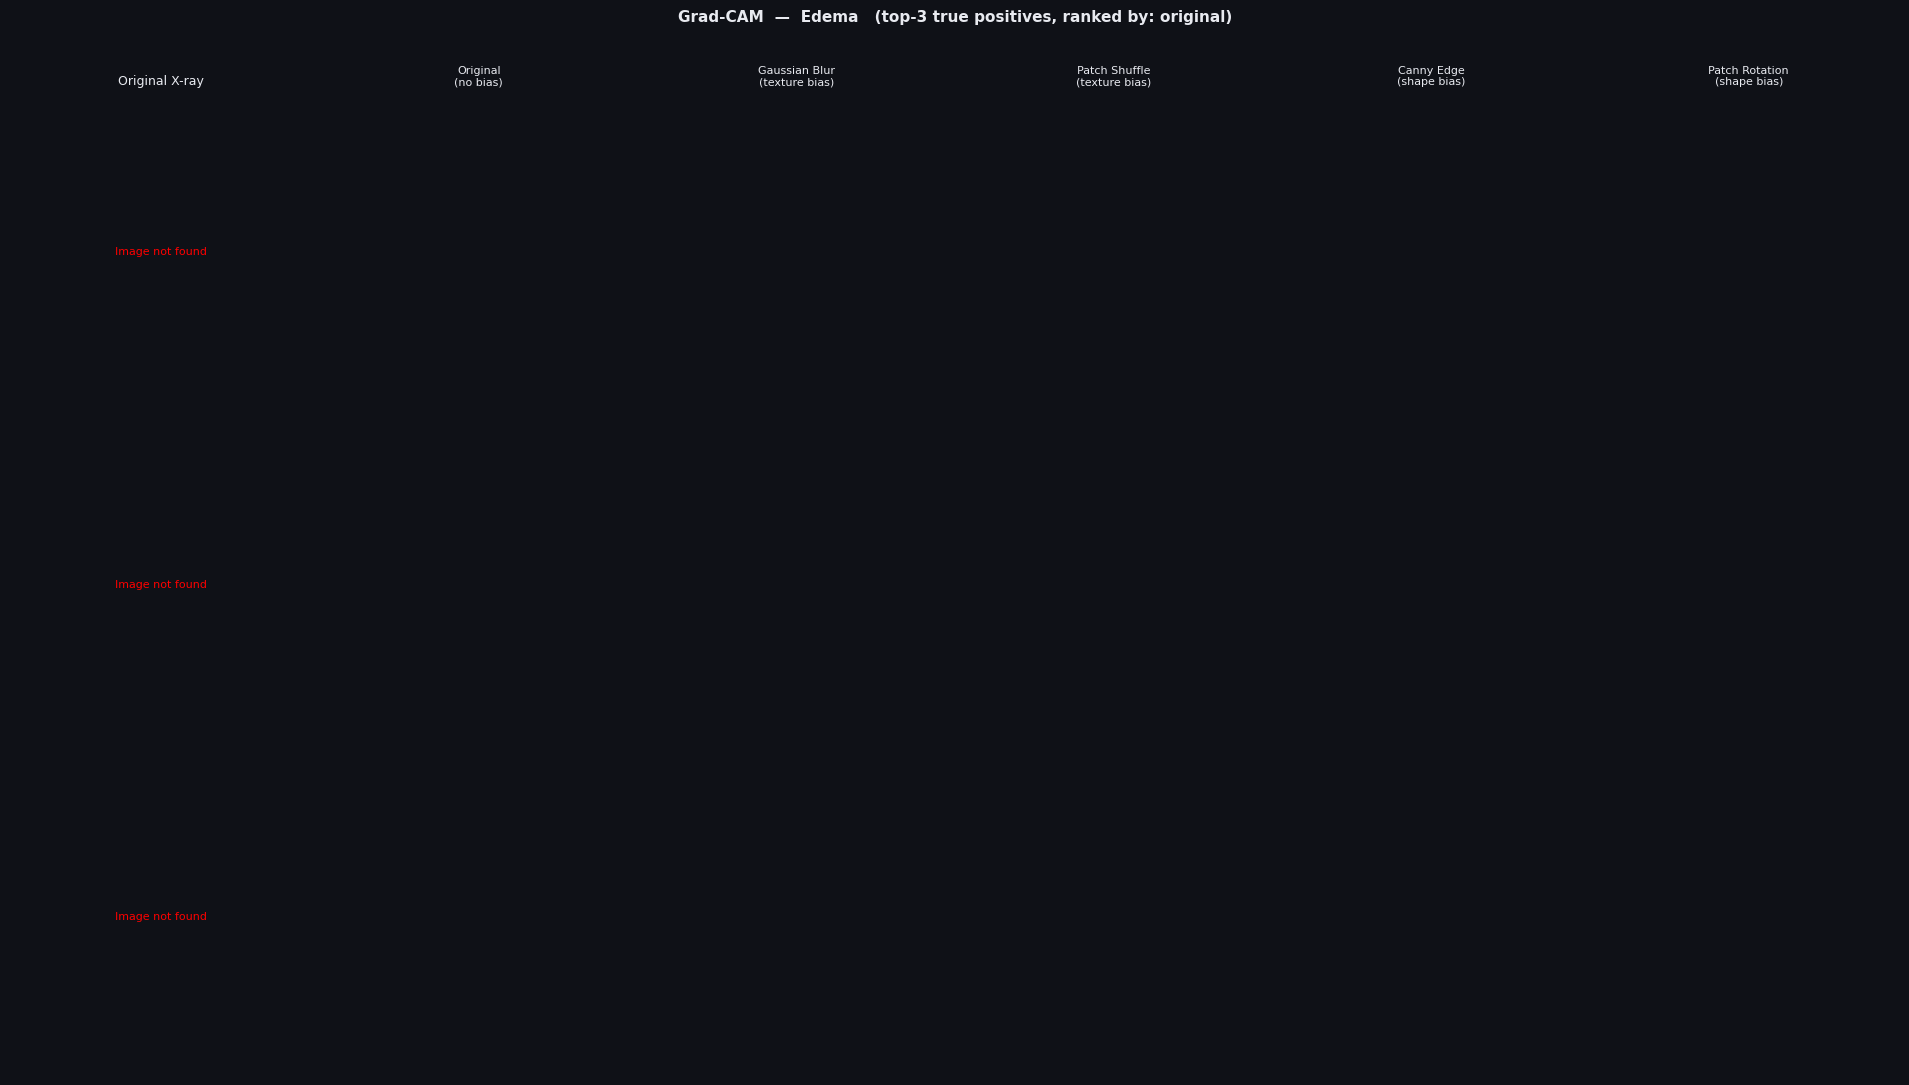

In [7]:
# ── Grad-CAM panels — one figure per label ────────────────────────────────────

plt.rcParams.update({'figure.facecolor': '#0f1117', 'axes.facecolor': '#0f1117'})

MODEL_DISPLAY = {
    'original': 'Original\n(no bias)',
    'gb':       'Gaussian Blur\n(texture bias)',
    'ps':       'Patch Shuffle\n(texture bias)',
    'ce':       'Canny Edge\n(shape bias)',
    'pr':       'Patch Rotation\n(shape bias)',
}

model_names = list(models.keys())
n_cols      = 1 + len(model_names)

for label, samples in top_images.items():
    if not samples:
        continue

    n_rows = len(samples)
    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.2 * n_cols, 3.4 * n_rows + 0.5),
        squeeze=False,
    )
    fig.patch.set_facecolor('#0f1117')

    axes[0, 0].set_title('Original X-ray', color='#e8eaf0', fontsize=9, pad=6)
    for ci, mname in enumerate(model_names, 1):
        axes[0, ci].set_title(MODEL_DISPLAY.get(mname, mname), color='#e8eaf0', fontsize=8, pad=6)

    for row, (rel_path, gt_val, pred_prob) in enumerate(samples):
        try:
            pil_img = load_pil(rel_path)
        except FileNotFoundError:
            for c in range(n_cols):
                axes[row, c].axis('off')
            axes[row, 0].text(0.5, 0.5, 'Image not found', ha='center', va='center',
                              color='red', fontsize=8, transform=axes[row, 0].transAxes)
            continue

        # Col 0 — raw X-ray
        axes[row, 0].imshow(np.array(pil_img.convert('L')), cmap='gray', vmin=0, vmax=255)
        axes[row, 0].set_ylabel(
            f'GT={int(gt_val)}  scored={pred_prob:.3f}',
            color='#aab0c4', fontsize=7, rotation=0, labelpad=65, va='center'
        )
        axes[row, 0].axis('off')

        # Cols 1-N — Grad-CAM per model
        for ci, mname in enumerate(model_names, 1):
            ax = axes[row, ci]
            if label not in model_labels[mname]:
                ax.set_facecolor('#1a1d27')
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center',
                        color='#666888', fontsize=9, transform=ax.transAxes)
                ax.axis('off')
                continue

            class_idx = model_labels[mname].index(label)
            try:
                tensor  = load_tensor(rel_path)
                cam     = grad_cams[mname].generate(tensor, class_idx)
                ax.imshow(overlay(pil_img, cam))
                with torch.no_grad():
                    p = torch.sigmoid(models[mname](tensor.to(DEVICE))[0, class_idx]).item()
                ax.set_xlabel(f'p = {p:.3f}', color='#e8eaf0', fontsize=7.5)
            except Exception as exc:
                ax.text(0.5, 0.5, str(exc), ha='center', va='center',
                        color='red', fontsize=6, wrap=True, transform=ax.transAxes)
            ax.axis('off')

    fig.suptitle(
        f'Grad-CAM  —  {label}   (top-{TOP_N} true positives, ranked by: {SCORING_MODEL})',
        color='#e8eaf0', fontsize=11, fontweight='bold', y=1.01,
    )
    fig.tight_layout()

    out_path = _OUT_DIR / f'gradcam_{label.replace(" ", "_").lower()}.png'
    fig.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='#0f1117')
    print(f'Saved: {out_path}')
    plt.show()
    plt.close(fig)

In [ ]:
# ── Probability comparison table ──────────────────────────────────────────────

col_w = 10
header = f'{"Label":<33} {"Image":<28}' + ''.join(f'{n:>{col_w}}' for n in model_names)
print(header)
print('-' * len(header))

for label, samples in top_images.items():
    for rel_path, gt_val, _ in samples:
        try:
            tensor = load_tensor(rel_path)
        except FileNotFoundError:
            continue

        row_probs = []
        for mname in model_names:
            if label not in model_labels[mname]:
                row_probs.append(float('nan'))
            else:
                ci = model_labels[mname].index(label)
                with torch.no_grad():
                    row_probs.append(
                        torch.sigmoid(models[mname](tensor.to(DEVICE))[0, ci]).item()
                    )

        valid = [p for p in row_probs if not (p != p)]
        best  = max(valid) if valid else None

        print(f'{label:<33} {Path(rel_path).name:<28}', end='')
        for p in row_probs:
            if p != p:
                print(f'{"N/A":>{col_w}}', end='')
            else:
                tag = '*' if p == best else ' '
                print(f'{p:>{col_w-1}.4f}{tag}', end='')
        print()

## What to look for

| Observation | Interpretation |
|---|---|
| `original` heatmap on known anatomy (heart, pleura, lungs) | Model learned real clinical features |
| `gb` heatmap similar to `original` | Blur preserved global structure — model transfers well |
| `ps` heatmap scattered / fragmented | Patch shuffle destroyed spatial layout during training |
| `ce` heatmap on thin lines / borders only | Canny model attends to contours, not density |
| `pr` heatmap close to `original` | Patch rotation preserved global layout |
| Biased model `p=` lower than original | Stylization degraded the diagnostic signal |
| Biased model `p=` **higher** than original | Label is detectable from the bias-preserved features (e.g. Cardiomegaly via shape) |